# Options Market Making Simulator — Analysis

This notebook runs the full pipeline end to end: simulate a stock price path and random order flow, quote and trade against that flow with the Avellaneda-Stoikov market maker, delta-hedge the resulting inventory, and attribute the P&L to spread income, theta decay, and gamma. It then compares the AS quoting strategy against a naive fixed-spread strategy across many simulated paths.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt

from src.simulator import simulate_gbm, simulate_order_flow
from src.black_scholes import call_price
from src.market_maker import MarketMaker
from src.hedger import rebalance
from src.pnl import mark_to_market, decompose_step

plt.rcParams["figure.figsize"] = (10, 4)
np.random.seed(42)

## 1. Simulation parameters

A 3-month at-the-money call, quoted daily, against symmetric Poisson order flow (3 buy / 3 sell orders per day on average) — matching the defaults used throughout the README and test suite.

In [2]:
S0, K, mu, sigma, r = 100, 100, 0.05, 0.20, 0.05
dt = 1 / 252                 # one trading day
T = 0.25                     # 3 months to expiry
n_steps = round(T / dt)      # 63 trading days
lambda_buy, lambda_sell = 3, 3

print(f"n_steps = {n_steps} trading days")

n_steps = 63 trading days


## 2. One simulated path, in detail

Simulate a single price path and order flow sequence, then run it through the market maker and hedger step by step, recording inventory, hedge position, and P&L along the way.

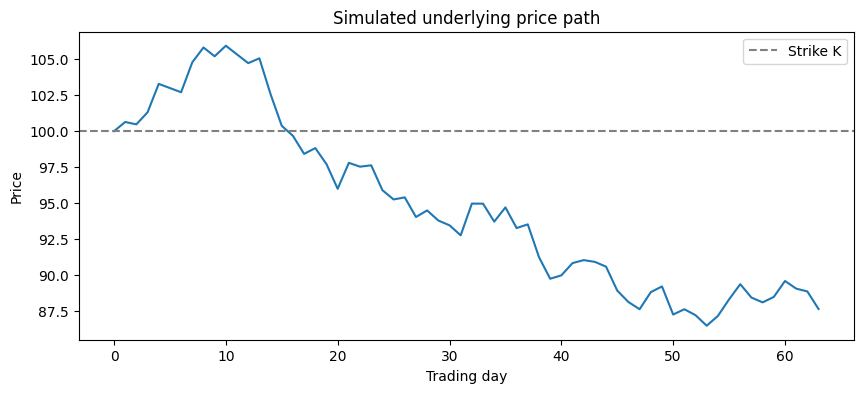

In [3]:
prices = simulate_gbm(S0, mu, sigma, dt, n_steps, n_paths=1)[:, 0]
order_flow = simulate_order_flow(n_steps, lambda_buy, lambda_sell)

plt.plot(prices)
plt.axhline(K, color="gray", linestyle="--", label="Strike K")
plt.title("Simulated underlying price path")
plt.xlabel("Trading day")
plt.ylabel("Price")
plt.legend()
plt.show()

In [4]:
mm = MarketMaker(S0, K, T, r, sigma)

inventory_path = np.zeros(n_steps)
hedge_path     = np.zeros(n_steps)
mtm_path       = np.zeros(n_steps)
cum_spread     = np.zeros(n_steps)
cum_theta      = np.zeros(n_steps)
cum_gamma      = np.zeros(n_steps)

running_spread = running_theta = running_gamma = 0.0

for t in range(n_steps):
    T_rem = T - t * dt
    S_now, S_next = prices[t], prices[t + 1]

    # spread edge captured this step = cash received minus the mid-value of what traded
    mid_before = call_price(S_now, K, T_rem, r, sigma)
    cash_flow = mm.process_order_flow(order_flow[t], S_now, T_rem)
    running_spread += cash_flow - order_flow[t] * mid_before

    rebalance(mm, S_now, T_rem)

    theta_pnl, gamma_pnl = decompose_step(mm, S_now, S_next, T_rem, dt)
    running_theta += theta_pnl
    running_gamma += gamma_pnl

    inventory_path[t] = mm.inventory
    hedge_path[t]     = mm.hedge_pos
    mtm_path[t]       = mark_to_market(mm, S_now, T_rem)
    cum_spread[t]     = running_spread
    cum_theta[t]      = running_theta
    cum_gamma[t]      = running_gamma

# settle the final position at intrinsic value (the option has actually expired)
S_final = prices[n_steps]
final_option_value = mm.inventory * max(S_final - K, 0)
final_hedge_value   = mm.hedge_pos * S_final
final_total = mm.cash + final_option_value + final_hedge_value

print(f"final inventory:   {mm.inventory}")
print(f"final hedge pos:   {mm.hedge_pos:.4f} shares")
print(f"final cash:        {mm.cash:.2f}")
print(f"final total P&L:   {final_total:.2f}")

final inventory:   8
final hedge pos:   -0.0000 shares
final cash:        105.71
final total P&L:   105.71


### Inventory and hedge position over time

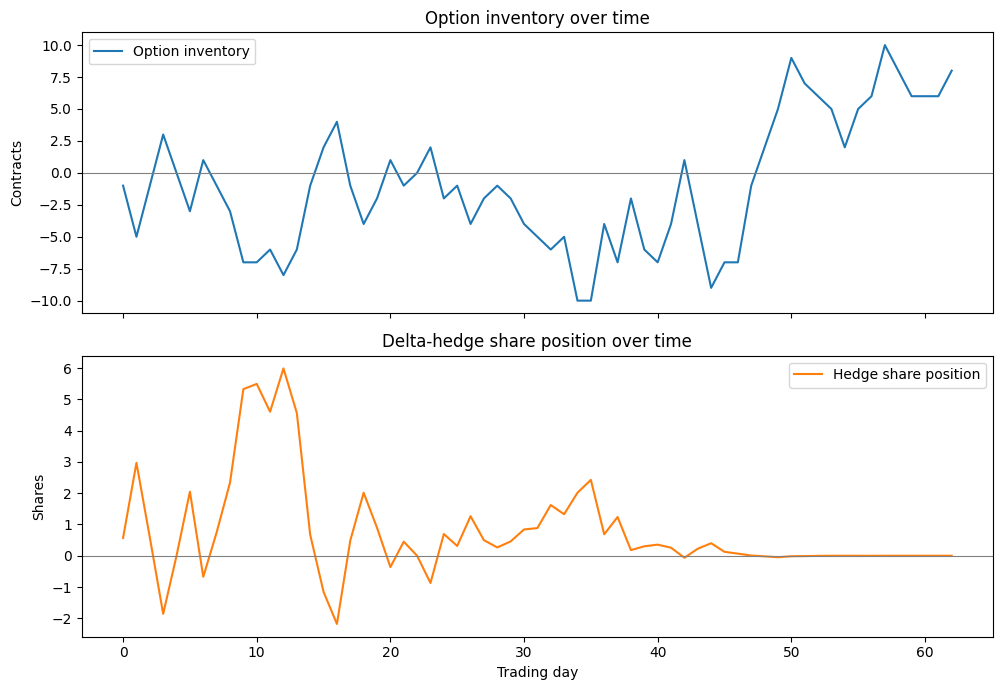

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(inventory_path, label="Option inventory")
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_ylabel("Contracts")
axes[0].set_title("Option inventory over time")
axes[0].legend()

axes[1].plot(hedge_path, color="tab:orange", label="Hedge share position")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_ylabel("Shares")
axes[1].set_xlabel("Trading day")
axes[1].set_title("Delta-hedge share position over time")
axes[1].legend()

plt.tight_layout()
plt.show()

### P&L decomposition

Cumulative spread income, theta decay, and gamma P&L, plotted against the actual mark-to-market P&L path. The three components should roughly reconstruct the actual path — the gap between them is the residual from discrete (once-daily) hedging rather than continuous hedging, plus the terminal settlement at intrinsic value rather than a continuously marked Black-Scholes price.

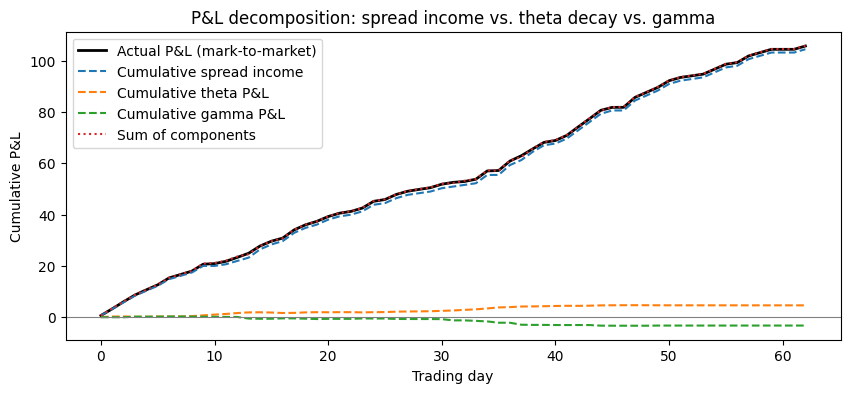

spread income:  104.46
theta P&L:      4.62
gamma P&L:      -3.26
sum of parts:   105.83
actual total:   105.71
residual:       -0.11  (discrete-hedging error)


In [6]:
plt.plot(mtm_path, label="Actual P&L (mark-to-market)", linewidth=2, color="black")
plt.plot(cum_spread, label="Cumulative spread income", linestyle="--")
plt.plot(cum_theta, label="Cumulative theta P&L", linestyle="--")
plt.plot(cum_gamma, label="Cumulative gamma P&L", linestyle="--")
plt.plot(cum_spread + cum_theta + cum_gamma, label="Sum of components", linestyle=":", color="tab:red")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("P&L decomposition: spread income vs. theta decay vs. gamma")
plt.xlabel("Trading day")
plt.ylabel("Cumulative P&L")
plt.legend()
plt.show()

residual = final_total - (cum_spread[-1] + cum_theta[-1] + cum_gamma[-1])
print(f"spread income:  {cum_spread[-1]:.2f}")
print(f"theta P&L:      {cum_theta[-1]:.2f}")
print(f"gamma P&L:      {cum_gamma[-1]:.2f}")
print(f"sum of parts:   {cum_spread[-1] + cum_theta[-1] + cum_gamma[-1]:.2f}")
print(f"actual total:   {final_total:.2f}")
print(f"residual:       {residual:.2f}  (discrete-hedging error)")

## 3. Avellaneda-Stoikov vs. a naive fixed-spread quoter

The README frames the AS strategy as a rigorous benchmark against naive fixed-spread quoting. To test that, run many independent price/order-flow paths through both:

- **AS market maker** — the existing `MarketMaker`, which skews its reservation price with inventory.
- **Naive market maker** — quotes a fixed spread around the Black-Scholes mid with no inventory skew at all. Its half-spread is set equal to the AS model's constant (order-flow) term, so both strategies quote a comparable spread width on average — isolating the effect of the inventory skew itself rather than conflating it with a different average spread.

Both are delta-hedged identically, and each pair of runs shares the same simulated price path and order flow, so the comparison is apples-to-apples.

In [7]:
GAMMA, KAPPA = mm.gamma, mm.kappa
naive_half_spread = ((2 / GAMMA) * np.log(1 + GAMMA / KAPPA)) / 2

class NaiveMarketMaker(MarketMaker):
    """Fixed spread around the Black-Scholes mid; no inventory skew."""
    def get_quotes(self, S, T_remaining):
        mid = call_price(S, self.K, T_remaining, self.r, self.sigma)
        return mid - naive_half_spread, mid + naive_half_spread


def run_path(mm_class, prices, order_flow):
    sim_mm = mm_class(S0, K, T, r, sigma)
    max_abs_inventory = 0
    for t in range(n_steps):
        T_rem = T - t * dt
        sim_mm.process_order_flow(order_flow[t], prices[t], T_rem)
        rebalance(sim_mm, prices[t], T_rem)
        max_abs_inventory = max(max_abs_inventory, abs(sim_mm.inventory))

    S_f = prices[n_steps]
    total_pnl = sim_mm.cash + sim_mm.inventory * max(S_f - K, 0) + sim_mm.hedge_pos * S_f
    return total_pnl, max_abs_inventory


n_sims = 300
as_pnls, naive_pnls = np.zeros(n_sims), np.zeros(n_sims)
as_max_inv, naive_max_inv = np.zeros(n_sims), np.zeros(n_sims)

for i in range(n_sims):
    sim_prices = simulate_gbm(S0, mu, sigma, dt, n_steps, n_paths=1)[:, 0]
    sim_flow = simulate_order_flow(n_steps, lambda_buy, lambda_sell)

    as_pnls[i], as_max_inv[i] = run_path(MarketMaker, sim_prices, sim_flow)
    naive_pnls[i], naive_max_inv[i] = run_path(NaiveMarketMaker, sim_prices, sim_flow)

print(f"naive half-spread used for comparison: {naive_half_spread:.4f}")
print()
print(f"AS strategy:    mean P&L={as_pnls.mean():.2f}  std={as_pnls.std():.2f}  avg max|inventory|={as_max_inv.mean():.1f}")
print(f"Naive strategy: mean P&L={naive_pnls.mean():.2f}  std={naive_pnls.std():.2f}  avg max|inventory|={naive_max_inv.mean():.1f}")

naive half-spread used for comparison: 0.6454

AS strategy:    mean P&L=78.67  std=13.25  avg max|inventory|=22.5
Naive strategy: mean P&L=78.65  std=13.25  avg max|inventory|=22.5


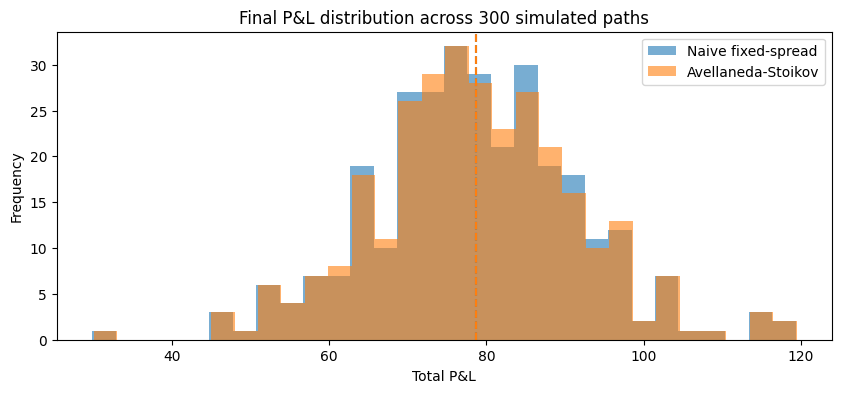

In [8]:
fig, ax = plt.subplots()
ax.hist(naive_pnls, bins=30, alpha=0.6, label="Naive fixed-spread")
ax.hist(as_pnls, bins=30, alpha=0.6, label="Avellaneda-Stoikov")
ax.axvline(naive_pnls.mean(), color="tab:blue", linestyle="--")
ax.axvline(as_pnls.mean(), color="tab:orange", linestyle="--")
ax.set_title(f"Final P&L distribution across {n_sims} simulated paths")
ax.set_xlabel("Total P&L")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

## 4. Why the two strategies look so similar — a real limitation, not a bug

The histograms above land almost on top of each other, and `avg max|inventory|` comes out **identical** between the two strategies. That's a genuinely useful (if humbling) finding, and it's worth understanding why rather than papering over it.

`simulate_order_flow` draws buy/sell order counts from `Poisson(lambda_buy)` / `Poisson(lambda_sell)` with **fixed** lambdas — the arrival rate never depends on where the market maker's quotes sit relative to the theoretical mid. But the Avellaneda-Stoikov derivation assumes order arrival intensity falls off exponentially with distance from the quote, λ(δ) = A·e^(−κδ) — in other words, it assumes that skewing your quotes changes *how much* flow you get, not just the price you get it at. That assumption is what makes the reservation-price skew actually self-correct inventory in the original theory: a skewed quote is supposed to attract more of the flow that reduces your position and less of the flow that grows it.

This simulator doesn't wire that connection up. Whatever `order_flow[t]` says arrives, arrives — it is entirely exogenous to the market maker's quotes. So the AS skew still does something real (it changes the *price* at which each trade executes, and the P&L decomposition above is still a faithful breakdown of theta/gamma/spread), but it can't do the thing that would actually show up in a head-to-head P&L comparison: change the realized inventory path. Since inventory is identical between the two strategies by construction, of course their P&L distributions end up nearly identical too.

**The natural fix**, left as a next step rather than implemented here: make `simulate_order_flow` (or a variant of it) scale `lambda_buy` / `lambda_sell` by the distance of the market maker's quotes from the mid, e.g. `lambda_buy * exp(-kappa * (ask - mid))`. That would make the simulator match the assumptions AS is actually derived under, and it's the change that would be needed before a Monte Carlo comparison like this one could show AS meaningfully outperforming a naive quoter on realized inventory risk.

## 5. Takeaways

- The P&L decomposition in Section 2 confirms the core mechanic works as designed: spread income accumulates from captured half-spreads, theta and gamma move in the directions the Black-Scholes Greeks predict, and the small residual is attributable to discrete (daily) rather than continuous hedging.
- The gamma-theta tradeoff is visible directly in the decomposition plot: theta P&L accrues steadily while gamma P&L jumps around with the size of each day's price move — exactly the tension the project's README describes as the central risk of options market making.
- The AS-vs-naive comparison in Section 3 turned up a real limitation rather than the expected result: because order flow arrival in `simulate_order_flow` doesn't respond to quote placement, the inventory-management benefit AS is supposed to provide over naive fixed-spread quoting isn't actually exercised by this simulator yet. That's a concrete, well-scoped next extension rather than a dead end.